In [4]:
import random
import numpy as np
import math
import time 
from matplotlib import pyplot as plt


# Ejercicio 1

Implemente las estructuras de datos y algoritmos básicos para la solución de un problema mediante **algoritmos genéticos**.  
Pruebe estas rutinas y compare los resultados con un **método de gradiente descendiente** para buscar el mínimo global de las siguientes funciones:

1. $ f(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512] $

2. $ f(x, y) = (x^2 + y^2)^{0.25} \cdot \Big[\sin^2\big(50(x^2 + y^2)^{0.1}\big) + 1\Big], \quad (x, y) \in [-100, 100] $ 



# Algoritmo Genetico

## 1. Representacion de individuos
Para $f(x)$: cada cromosoma representa un valor de $x$ con $x \in [512, 512]$ lo que haremos sera tomar 
$$
\underbrace{\boxed{b_{13}}}_{\text{signo}}
\underbrace{\boxed{b_{12}}\boxed{b_{11}}\boxed{b_{10}}\boxed{b_{9}}\boxed{b_{8}}\boxed{b_{7}}\boxed{b_{6}}\boxed{b_{5}}\boxed{b_{4}}}_{\text{parte entera (9 bits)}}
\underbrace{\boxed{b_{3}}\boxed{b_{2}}\boxed{b_{1}}\boxed{b_{0}}}_{\text{decimal (4 bits)}}
$$

donde: 
* Si el bit de signo es 0 $\rightarrow$ representa un numero positivo
* Si el bit de signo es 1 $\rightarrow$ representa un numero negativo

In [2]:
def decodificar(cromosoma): 
  sgn = cromosoma[0]
  decimal_bin = cromosoma[-4:]
  # Convertir cada bit de string a int antes de multiplicar
  parte_decimal = int(decimal_bin[0]) * (1/2) + int(decimal_bin[1]) * (1/4) + int(decimal_bin[2]) * (1/8) + int(decimal_bin[3]) * (1/16)
  parte_entera = int(cromosoma[1:-4], 2)

  if sgn == '1': 
    return -(parte_entera + parte_decimal)
  else: 
    return  parte_entera + parte_decimal

### Ejemplos de prueba

In [3]:
# Bit signo: 0 (positivo)
# Parte entera: 100000001 = 257 en decimal
# Parte decimal: 1000 = 1*(1/2) + 0*(1/4) + 0*(1/8) + 0*(1/16) = 0.5
# Resultado esperado: 257.5
cromosoma1 = "01000000011000"
resultado1 = decodificar(cromosoma1)
print(f"Cromosoma: {cromosoma1}")
print(f"Resultado: {resultado1}")
print(f"Esperado: 257.5")
print()

# Bit signo: 1 (negativo)
# Parte entera: 100000001 = 257 en decimal
# Parte decimal: 1000 = 0.5
# Resultado esperado: -257.5
cromosoma2 = "11000000011000"
resultado2 = decodificar(cromosoma2)
print(f"Cromosoma: {cromosoma2}")
print(f"Resultado: {resultado2}")
print(f"Esperado: -257.5")
print()


Cromosoma: 01000000011000
Resultado: 257.5
Esperado: 257.5

Cromosoma: 11000000011000
Resultado: -257.5
Esperado: -257.5



## 2. Operadores de seleccion

### Ruleta
1. Calculamos el fitness total
$$
F = \sum_{i=1}^N f_i
$$
donde $f_i$ es el fitness del individuo $i$ y $N$ es el tamaño de la poblacion.

2. Calculamos la probabilidad
$$
p_i = \frac{f_i}{F} 
$$
en donde cada individuo recibe una probabilidad proporcional a su fitness

3. Construimos intervalos con la probabilidad de cada uno de $[0, 1]$

4. Sorteamos
  * Generamos un numero aleatorio $r \in [0, 1]$
  * Buscas en que intervalo cae $r$
  * Ese es el individuo seleccionado
  * Repetimos hasta tener la cantidad de padres necesarias

In [4]:
def ruleta(poblacion, fitness): 
  fitness_total = sum(fitness) 
  probabilidades = []

  for individuo in range(len(poblacion)): 
    prob = fitness[individuo] / fitness_total
    probabilidades.append(prob)

  acumulador = 0
  ruleta = []
  for prob in probabilidades: 
    acumulador += prob
    ruleta.append(acumulador)

  p = random.random()

  for i, probabilidad in enumerate(ruleta): 
    if p <= probabilidad: 
      ganador = i

  return poblacion[ganador]

### Competencia
1. Elegimos al azar $k$ individuos de la poblacion
2. Comparamos sus fitness
3. El que tenga el mejor fitness gana el torneo y es seleccionado como padre
4. Repetimos el proceso hasta tener todos los padres necesarios

In [29]:
def competencia(poblacion, fitness, k=2): 
  # elegir k índices al azar
  indices = random.sample(range(len(poblacion)), k)
    
  # buscar el índice del que tenga mejor fitness
  ganador_local = max(indices, key=lambda i: fitness[i])
    
  return poblacion[ganador_local]


### Ventanas
1. Ordenamos la poblacion de mejor a peor segun su fitness
2. Dividimos la lista ordenada en ventanas
3. De cada ventana elegimos al azar un individuo

In [6]:
def ventanas(poblacion, fitness, n_padres): 
  ordenados = sorted(zip(poblacion, fitness), key=lambda x: x[1], reverse=True)
  padres = []
  N = len(poblacion)

  for i in range(n_padres): 
    # Elegimos el tamaño de la ventana
    q = random.randint(1, N)

    # La ventana sera igual a los mejores q
    ventana = ordenados[:q]

    elegido = random.choice(ventana)
    padres.append(elegido[0])

  return padres 

## 3. Cruza y mutacion

In [7]:
def cruza(padre1, padre2): 
  punto = random.randint(1, len(padre1)-1)

  hijo1 = padre1[:punto] + padre2[punto:]
  hijo2 = padre2[:punto] + padre1[punto:]

  return hijo1, hijo2

In [8]:
def mutacion(individuo, prob = 0.01): 
  # Incertamos una probabilidad de mutacion ya que no siempre mutamos
  # Por ejemplo con prob = 0.01 cada bit tiene un 1% de cambiar

  prob_i = np.random.rand()
  if prob_i < prob: 
    pos = np.random.choice(len(individuo))
    individuo_mutado = list(individuo)
    if(individuo_mutado[pos] == "0"): 
      individuo_mutado[pos] == "1"
    else: 
      individuo_mutado[pos] = "0"
    
    individuo = "".join(individuo_mutado)
  
  return individuo

## 4. Elitimos
El elitismo consite en copiar el mejor individuo de la generacion actual a la proxima sin modificarlo. De esa manera nos aseguramos que la mejor solucion encontrada hasta ahora nunca se pierda por culpa de la cruza o la mutacion

In [22]:
def elitismo(poblacion, fitness): 
  elite_index = sorted(range(len(fitness)), key=lambda i: fitness[i], reverse=True)[0]
  return poblacion[elite_index]

In [14]:
def inicializar_poblacion(pop_size, n_bits): 
  poblacion = []
  for _ in range(pop_size): 
    cromosoma = ""
    for _ in range(n_bits): 
      cromosoma += random.choice("01")
    poblacion.append(cromosoma)
  return poblacion

In [62]:
def fitness_function(x): 
  return (x * math.sin(math.sqrt(abs(x)))) # -f1 para obtener la aptitud mínima en vez de máxima


In [53]:
def algoritmo_genetico(fitness_func, pop_size,n_bits, generaciones = 100, max_estable=20): 
  inicio = time.time()
  # 1. Inicializar poblacion
  poblacion = inicializar_poblacion(pop_size, n_bits)

  # Variables de control
  cont_estabilidad = 0
  apt_max = 1e-6
  aptitudes_max = []
  
  # 2. Obtenemos la funcion de aptitud para cada individuo
  for gen in range(generaciones): 
    valores = []
    for ind in poblacion:
      x = decodificar(ind)   # convertir cromosoma binario en número real
      valores.append(x)

    fitness = []
    for x in valores:
      f = fitness_func(x)     # calcular el valor de la función objetivo
      fitness.append(f)
    
    # 3. Elegimos al mejor de la poblacion
    mejor = elitismo(poblacion, fitness)
  
    # 4. Inicializamos la nueva poblacion
    nueva_pob = []

    nueva_pob.append(mejor)

    while(len(nueva_pob) < len(poblacion)): 
      # 5. Realizamos la seleccion
      padre1 = competencia(poblacion, fitness)
      padre2 = competencia(poblacion, fitness)

      # 6. Cruza
      hijo1, hijo2 = cruza(padre1, padre2)

      # 7. Mutacion
      hijo1 = mutacion(hijo1)
      hijo2 = mutacion(hijo2)

      # 8. Lo agregamos a la nueva poblacion
      nueva_pob.append(hijo1)
      if len(nueva_pob) < len(poblacion):  # no pasarse del tamaño
        nueva_pob.append(hijo2)
      
    # 9. Evaluacion de estabilidad
    if np.isclose(max(fitness), apt_max):
      cont_estabilidad += 1
    else:
      cont_estabilidad = 0

    if cont_estabilidad >= max_estable:
      print(f"Se alcanzó estabilidad en la generación {gen}")
      break

    # Actualizar para la siguiente generación
    poblacion = nueva_pob
    aptitudes_max.append(max(fitness))
    apt_max = max(fitness)

  # Seleccionar mejor individuo final
  valores = [decodificar(ind) for ind in poblacion]
  fitness = [fitness_func(x) for x in valores]
  mejor_idx = max(range(len(fitness)), key=lambda i: fitness[i])
  mejor_cromosoma = poblacion[mejor_idx]
  mejor_valor = valores[mejor_idx]
  mejor_fit = fitness[mejor_idx]

  # Gráfico de evolución
  plt.plot(range(len(aptitudes_max)), aptitudes_max)
  plt.xlabel("Generación")
  plt.ylabel("Mejor fitness")
  plt.title("Evolución del AG")
  plt.show()
    
  fin = time.time()
  print(f'El algoritmo terminó en la generación {gen} en {round(fin-inicio,4)} segundos.')

  return mejor_cromosoma

    

El mínimo de la función está en (418.909090909091 y es -418.4481325008988)


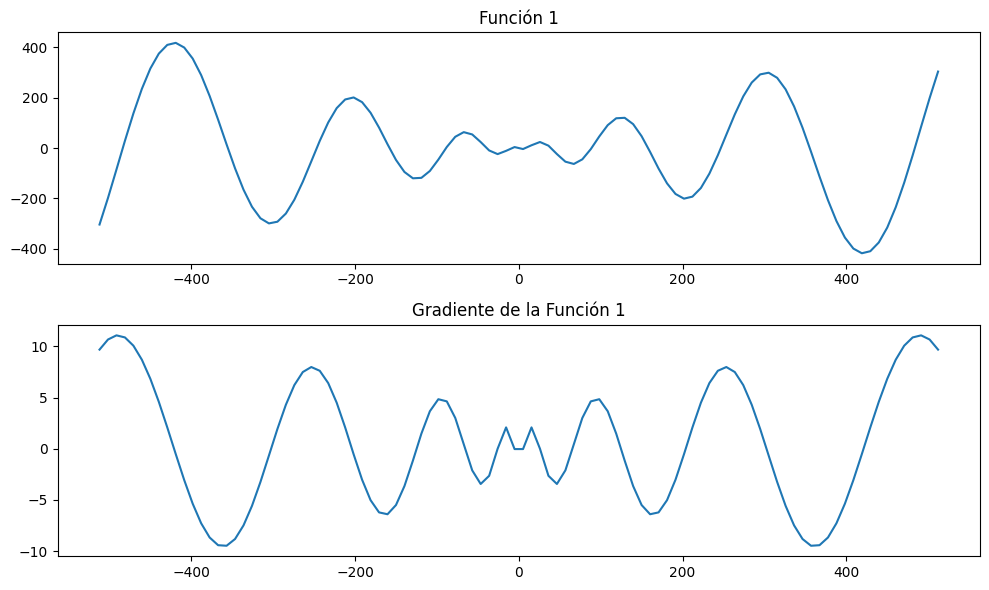

In [5]:

def f1(x):
    return -x*np.sin(np.sqrt(abs(x)))
def grad_f1(x):
    return -np.sin(np.sqrt(abs(x))) - (x**2 * np.cos(np.sqrt(abs(x))))/(2*abs(x)*np.sqrt(abs(x)))

x = np.linspace(-512,512,100)
y_f1 = f1(x)
y_grad_f1 = grad_f1(x)

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,6))
ax1.plot(x,y_f1)
ax1.set_title('Función 1')
ax2.plot(x,y_grad_f1)
ax2.set_title('Gradiente de la Función 1')
plt.tight_layout()

print(f'El mínimo de la función está en ({x[np.argmin(y_f1)]} y es {np.min(y_f1)})')

# grafica de los individuos por generación para ver cómo se van moviendo por generación


Se alcanzó estabilidad en la generación 32


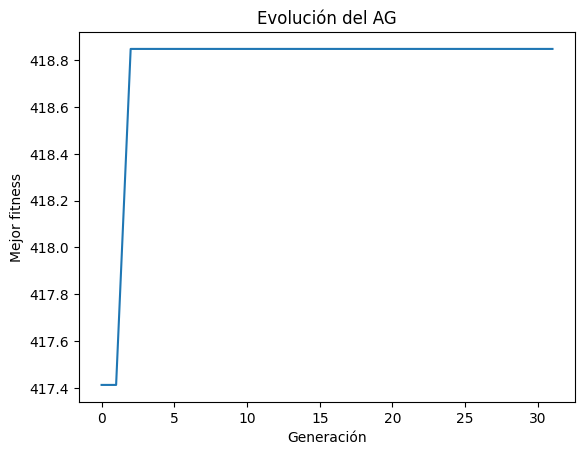

El algoritmo terminó en la generación 32 en 0.0718 segundos.
Minimo encontrado 419.9375 y su valor es -418.8487554216636


In [68]:
ganador = algoritmo_genetico(fitness_function, 50,14, generaciones = 1000, max_estable=30)
print(f"Minimo encontrado {decodificar(ganador)} y su valor es {f1(decodificar(ganador))}")

## Obteniendo el minimo por el metodo del gradiente descendiente

In [70]:
u = 0.01
it = 1000

x = np.random.randint(-512,512)

for i in range(x): 
  x = x - u*grad_f1(x)

print(f"Minimo encontrado en {x}, vale {f1(x)}")

Minimo encontrado en -478, vale 60.9874168924627
